In [17]:
import warnings
warnings.filterwarnings("ignore")

### Schritt 0.5 - Visualisierung des Grids

(Ist glaube ich hilfreich es einmal am Anfang zu sehen) :^)

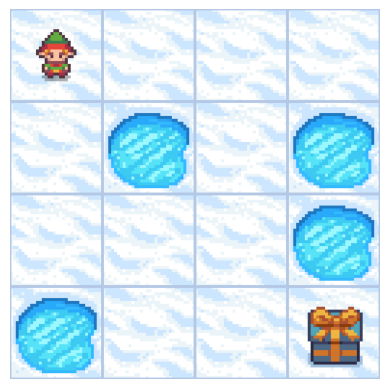

State grid (zur Veranschaulichung welcher Zustand sich wo befindet):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]


In [27]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

env = gym.make("FrozenLake-v1", render_mode="rgb_array", is_slippery=True)

state, _ = env.reset(seed=42)

img = env.render()
plt.imshow(img)
plt.axis("off")
plt.show()

num_states = env.observation_space.n
grid_size = int(np.sqrt(num_states))
state_grid = np.arange(num_states).reshape((grid_size, grid_size))
print("State grid (zur Veranschaulichung welcher Zustand sich wo befindet):")
print(state_grid)

### Schritt 1

Aufsetzen eines RL Environments, welches dabei helfen soll die einzelnen Schritte des Reinforcement Learnings zu verstehen, selber auszuprobieren und auch sich besser einzuprägen als nur Quellen durchzulesen, Tutorials durchzugehen und sonstiges.

In [28]:
import gymnasium as gym     # importiert die Gymnasium-Bibliothek die eine Sammlung von Umgebungen für Reinforcement Learning enthält z.b. frozenlake, cartpole, etc.
env = gym.make("FrozenLake-v1", render_mode="rgb_array", is_slippery=False) # is slippery=False bedeutet, dass die Umgebung deterministisch ist, d.h. die Aktionen führen immer zum gleichen Ergebnis. Das erleichtert das Lernen, da es keine zufälligen Elemente gibt, die das Verhalten beeinflussen könnten oder das ein State mehrmals mal hintereinander kommt
# später wird noch is_slippery=True verwendet, damit die Umgebung stochastisch ist, d.h. die Aktionen können zu unterschiedlichen Ergebnissen führen, was das Lernen realistischer macht, aber auch schwieriger
state, _ = env.reset(seed=42)   # deterministische Umgebung, damit die Ergebnisse reproduzierbar sind

print("Start state:", state) 

Start state: 0


### Schritt 2 - Aktion ausführen

In dem folgenden Abschnitt soll einer der Hauptbestanteile des RL eingesetzt werden - die Aktion.
Einfach erklärt funktioneiren Aktionen wie folgt:
Eine Aktion wird ausgeführt -> Welt reagiert -> man sieht ein Ergebnis

In [29]:
action = 2 # In der FrozenLake-Umgebung gelten folgenden Aktionen:  0: links, 1: unten, 2: rechts, 3: oben

action_names = {
    0: "links",
    1: "unten",
    2: "rechts",
    3: "oben"
}

next_state, reward, done, truncated, _ = env.step(action) # Aktion im Env ausführen
# next_state = neuer Zustand nach der Aktion
# reward = Belohnung/Bestrafung die der Agent für die Aktion erhält
# done = True wenn Ziel erreicht oder gefallen -> Episode ist beendet (Eine Episode ist die Sequenz von Zuständen, Aktionen, ... bis zum Ende einer Aufgabe z.B. könnte das Spiel einer Schachpartie eine ganze Episode sein mit dem Ergebnis: Sieg, Niederlage oder Unentschieden)
# truncated = True wenn die Episode aufgrund einer Zeitüberschrietung oder einer anderen Bedingung vorzeitig beendet wurde
# "_" = zusätzliche Informationen die von der Umgebung zurückgegeben werden können, aber hier nicht relevant sind

print("Next state:", next_state)    # Zeigt den Zustand nach der Aktion an   
print("Reward:", reward)            # Zeigt ob wir eine Belohnung oder Bestrafung erhalten haben
print("Done:", done)                # Zeigt ob die Episode beendet ist
print("Truncated:", truncated)      # Zeigt ob die Episode vorzeitig beendet wurde

Next state: 1
Reward: 0.0
Done: False
Truncated: False


### Schritt 3 - Der RL Loop

Der Reinforcement Learning Loop ist der Kern. Er beschreibt folgendes RL_Prinzip:
beobachten -> handeln -> lernen -> wiederholen

In [30]:
state, _ = env.reset(seed=42)   # deterministische Umgebung, damit die Ergebnisse reproduzierbar sind und das Environment wieder bei "0" ist

done = False    # Variable um zu überprüfen ob die Episode beendet ist

while not done:

    action = env.action_space.sample() # zufällige Aktion aus dem Aktionsraum der Umgebung auswählen -> exploration keine "intelligente" Aktion sondern zufällige Aktion

    state, reward, done, truncated, _ = env.step(action) # Aktion im Env ausführen und bekommt Feedback

    print("State:", state)            # Zeigt den aktuellen Zustand an
    print("Reward:", reward)          # Zeigt die Belohnung oder Bestrafung
    print("Done:", done)              # Zeigt ob die Episode beendet ist
    print("Truncated:", truncated)    # Zeigt ob die Episode vorzeitig beendet wurde

State: 0
Reward: 0.0
Done: False
Truncated: False
State: 0
Reward: 0.0
Done: False
Truncated: False
State: 0
Reward: 0.0
Done: False
Truncated: False
State: 0
Reward: 0.0
Done: False
Truncated: False
State: 0
Reward: 0.0
Done: False
Truncated: False
State: 1
Reward: 0.0
Done: False
Truncated: False
State: 2
Reward: 0.0
Done: False
Truncated: False
State: 6
Reward: 0.0
Done: False
Truncated: False
State: 2
Reward: 0.0
Done: False
Truncated: False
State: 6
Reward: 0.0
Done: False
Truncated: False
State: 10
Reward: 0.0
Done: False
Truncated: False
State: 14
Reward: 0.0
Done: False
Truncated: False
State: 10
Reward: 0.0
Done: False
Truncated: False
State: 6
Reward: 0.0
Done: False
Truncated: False
State: 10
Reward: 0.0
Done: False
Truncated: False
State: 9
Reward: 0.0
Done: False
Truncated: False
State: 5
Reward: 0.0
Done: True
Truncated: False


### Schritt 3.5 - Position im Grid

Aktuell sieht man immer nur eine Zahl z.B. State: 5, aber nicht wo genau man ist.
(Ausführlichere Variante von Schritt 3)

In [31]:
state, _ = env.reset(seed=42)   # deterministische Umgebung, damit die Ergebnisse reproduzierbar sind und das Environment wieder bei "0" ist

for step in range(20):                   # Schleife läuft, bis Episode normal oder vorzeitig endet

    action = env.action_space.sample()           # Wählt zufällige Aktion aus dem Aktionsraum

    print("Gewählte Aktion:", action, action_names[action])  # Gibt Zahl und Bedeutung der Aktion aus

    state, reward, done, truncated, _ = env.step(action)  # Führt Aktion aus und erhält Feedback vom Environment

    row = state // grid_size                    # Berechnet Zeile des neuen States
    col = state % grid_size                     # Berechnet Spalte des neuen States

    print("State:", state)                      # Gibt die neue State-Nummer aus
    print("Position:", (row, col))              # Gibt die Position im Grid aus
    print("Reward:", reward)                    # Gibt die Belohnung aus
    print("Done:", done)                        # Zeigt, ob Episode beendet ist
    print("Truncated:", truncated)              # Zeigt, ob Episode vorzeitig beendet wurde
    print("---")                                # Trennt die Schritte optisch -> sueht besser aus :)

    if done or truncated:                        # Überprüft, ob Episode normal oder vorzeitig beendet ist
        print("Episode beendet nach", step + 1, "Schritten.")
        break
    

Gewählte Aktion: 1 unten
State: 4
Position: (1, 0)
Reward: 0.0
Done: False
Truncated: False
---
Gewählte Aktion: 2 rechts
State: 5
Position: (1, 1)
Reward: 0.0
Done: True
Truncated: False
---
Episode beendet nach 2 Schritten.


### Schritt 4 - Transitions und Wahrscheinlichkeiten

Bisher wurde im Notebook is_slippery = false für eine deterministische Umgebung benutzt. Es gibt aber auch die stochastischen Umgebungen, bei denen Aktionen zu unterschiedlichen Ergebnissen führen können.

Zum Beispiel: 
Wenn es auf dem FrozenLake rutschig ist, kann es passieren, dass ich auf State 2 lande anstelle auf Feld 5
> *Eine Aktion führt nicht immer zu genau einem Ergebnis SONDERN zu mehreren Ergebenissen mit Wahrscheinlichkeiten.*

Das ist ein weiteres Grundkonzept für weitere Themen, wie: Q-Values, Value Functions etc.

In [32]:
env = gym.make("FrozenLake-v1", render_mode="rgb_array", is_slippery=True) # Hier muss is_slippery=True sein, damit die Umgebung stochastisch ist, d.h. die Aktionen können zu unterschiedlichen Ergebnissen führen (siehe Output)
state = 6  
action = 0

transitions = env.unwrapped.P[state][action]  # Zugriff auf die Übergangswahrscheinlichkeiten für den gegebenen Zustand und Aktion

print(f"Transitions für State {state} und Action {action}:\n")

for prob, next_state, reward, done in transitions: # Jede mögliche Transition durchgehen
    print(f"Wahrscheinlichkeit", prob)  # Wie wahrscheinlich ist diese Transition
    print(f"Next State:", next_state)   # In welchen State kommen wir?
    print(f"Reward:", reward)           # Welche Belohnung erhalten wir? >> Aktuell keine (kommt später)
    print(f"Done:", done)               # Ist die Episode danach beendet?
    print("---")

Transitions für State 6 und Action 0:

Wahrscheinlichkeit 0.3333333333333333
Next State: 2
Reward: 0.0
Done: False
---
Wahrscheinlichkeit 0.3333333333333333
Next State: 5
Reward: 0.0
Done: True
---
Wahrscheinlichkeit 0.3333333333333333
Next State: 10
Reward: 0.0
Done: False
---


### Schritt 4.5 - Mehrere States als Mini-Experiment

In [33]:
for state in range(4):
    for action in range(4):
        print(f"Transitions für State {state} und Action {action}:\n")
        transitions = env.unwrapped.P[state][action]  # Zugriff auf die Übergangswahrscheinlichkeiten für den gegebenen Zustand und Aktion
        for prob, next_state, reward, done in transitions: # Jede mögliche Transition durchgehen
            print(f"Wahrscheinlichkeit", prob)  # Wie wahrscheinlich ist diese Transition
            print(f"Next State:", next_state)   # In welchen State kommen wir?
            print(f"Reward:", reward)           # Welche Belohnung erhalten wir? >> Aktuell keine (kommt später)
            print(f"Done:", done)               # Ist die Episode danach beendet?
            print("---")
            

Transitions für State 0 und Action 0:

Wahrscheinlichkeit 0.3333333333333333
Next State: 0
Reward: 0.0
Done: False
---
Wahrscheinlichkeit 0.3333333333333333
Next State: 0
Reward: 0.0
Done: False
---
Wahrscheinlichkeit 0.3333333333333333
Next State: 4
Reward: 0.0
Done: False
---
Transitions für State 0 und Action 1:

Wahrscheinlichkeit 0.3333333333333333
Next State: 0
Reward: 0.0
Done: False
---
Wahrscheinlichkeit 0.3333333333333333
Next State: 4
Reward: 0.0
Done: False
---
Wahrscheinlichkeit 0.3333333333333333
Next State: 1
Reward: 0.0
Done: False
---
Transitions für State 0 und Action 2:

Wahrscheinlichkeit 0.3333333333333333
Next State: 4
Reward: 0.0
Done: False
---
Wahrscheinlichkeit 0.3333333333333333
Next State: 1
Reward: 0.0
Done: False
---
Wahrscheinlichkeit 0.3333333333333333
Next State: 0
Reward: 0.0
Done: False
---
Transitions für State 0 und Action 3:

Wahrscheinlichkeit 0.3333333333333333
Next State: 1
Reward: 0.0
Done: False
---
Wahrscheinlichkeit 0.3333333333333333
Next S

Wichtiger Hinweis: Man kann nicht in alle vier Richtungen rutschen, sondern nur in drei Richtungen und zwar in die Richtung in die man die Action ausführt sowie in die beiden benachbarten Richtungen
> links: links, oben unten

> rechts: rechts, oben, unten

> oben: oben, links, rechts

> unten: unten, links, rechts

### Schritt 5 - Return / Discounted Return / gamma

In [34]:
rewards = [0, 1, 1, 0, 1]                      # Beispielhafte Reward-Sequenz

gamma = 0.9                                    # Discount-Faktor

discounted_return = 0                          # Startwert für Return

for t, reward in enumerate(rewards):           # t = Zeitpunkt (0,1,2,...)
    
    discounted_return += (gamma ** t) * reward # Jeder Reward wird abgewertet
    
    print(f"Schritt {t}:")                     # Aktueller Zeitpunkt
    
    print(f"  Reward: {reward}")               # Aktueller Reward
    
    print(f"  Gewicht: {gamma**t:.4f}")        # Wie stark zählt dieser Reward
    
    print(f"  Aktueller Return: {discounted_return:.4f}")  # Gesamtwert bis jetzt
    
    print("-----")

gamma = 0.1 
discounted_return = 0 
print("Gamme = 0.1:")
for t, reward in enumerate(rewards):           
    discounted_return += (gamma ** t) * reward
    print(f"    {discounted_return:.4f}")

gamma = 0.99
discounted_return = 0 
print("Gamme = 0.99:")
for t, reward in enumerate(rewards):           
    discounted_return += (gamma ** t) * reward
    print(f"    {discounted_return:.4f}")

Schritt 0:
  Reward: 0
  Gewicht: 1.0000
  Aktueller Return: 0.0000
-----
Schritt 1:
  Reward: 1
  Gewicht: 0.9000
  Aktueller Return: 0.9000
-----
Schritt 2:
  Reward: 1
  Gewicht: 0.8100
  Aktueller Return: 1.7100
-----
Schritt 3:
  Reward: 0
  Gewicht: 0.7290
  Aktueller Return: 1.7100
-----
Schritt 4:
  Reward: 1
  Gewicht: 0.6561
  Aktueller Return: 2.3661
-----
Gamme = 0.1:
    0.0000
    0.1000
    0.1100
    0.1100
    0.1101
Gamme = 0.99:
    0.0000
    0.9900
    1.9701
    1.9701
    2.9307


### Schritt 6 - Policy definieren

Eine Policy ist an sich eine einfach Regel:
> Wenn ich in State X bin, mache ich Aktion Y

Hier definieren wir erstmal eine feste Policy, damit wir danach Values und Q-Values berechnen können

Wichtig: Für die Stabilität wird erstmal eine deterministische Umgebung genutzt

In [35]:
env = gym.make("FrozenLake-v1", render_mode="rgb_array", is_slippery=False)

state, _ = env.reset(seed=42)

num_states = env.observation_space.n
num_actions = env.action_space.n

grid_size = int(np.sqrt(num_states))

print("Anzahl States:", num_states)
print("Anzahl Actions:", num_actions)
print("Grid Size:", grid_size, "x", grid_size)

print(action_names) # Nochmalige Ausgabe der vier Aktionsschritte zur Erinnerung (vergesse selber die Reihenfolge manchmal :D)

# Definieren der Policy für das FrozenLake-Environement
policy = {
    0: 1, 1:0, 2:0, 3:0, 4:1, 6:3, 8:2, 9:2, 10:1, 13:2, 14:2
}

# Terminal-States des Environements definieren
terminal_states = [5, 7, 11, 12, 15]
print ("Terminal States:", terminal_states)

# Definieren welche Aktionen in welchem Schritt durchgeführt werden (siehe policy)
print("POLICY:")
for state in range(num_states):
    if state in terminal_states:
        print(f"State {state}: Terminal State keine Action verfügbar")
    else:
        print(f"State {state}: Aktion {policy[state]} ({action_names[policy[state]]})")

Anzahl States: 16
Anzahl Actions: 4
Grid Size: 4 x 4
{0: 'links', 1: 'unten', 2: 'rechts', 3: 'oben'}
Terminal States: [5, 7, 11, 12, 15]
POLICY:
State 0: Aktion 1 (unten)
State 1: Aktion 0 (links)
State 2: Aktion 0 (links)
State 3: Aktion 0 (links)
State 4: Aktion 1 (unten)
State 5: Terminal State keine Action verfügbar
State 6: Aktion 3 (oben)
State 7: Terminal State keine Action verfügbar
State 8: Aktion 2 (rechts)
State 9: Aktion 2 (rechts)
State 10: Aktion 1 (unten)
State 11: Terminal State keine Action verfügbar
State 12: Terminal State keine Action verfügbar
State 13: Aktion 2 (rechts)
State 14: Aktion 2 (rechts)
State 15: Terminal State keine Action verfügbar


### Schritt 7 - State-Value Function V(s)

V(s) bedeutuet hier:
> Wie gut ist dieser Zustand, wenn ich ab jetzt der Policy folge?

Also an sich startet man in einem State, macht immer das was die Policy sagt und summiert die zukünftigen Rewards

Bnutzen der Bellman-Idee:
> Wert des aktuellen Zustands = sofortige Reward + Wert des nächsten Zustands

als Formel:

> V(s) = reward + gamma * V(next_state)

In [44]:
gamma = 0.9
print("Gamma:", gamma)

# Funktion zur Berechnung der State-Value-Funktion V(s) für einen gegebenen Zustand s unter der definierten Policy
def compute_state_value(state, policy):
    if state in terminal_states:
        return 0
    
    action = policy[state]
    transition = env.unwrapped.P[state][action][0]

    prob, next_state, reward, done = transition

    return reward + gamma * compute_state_value(next_state, policy)

V = {}

for state in range(num_states):
    V[state] = compute_state_value(state, policy)

print("State Value V(s):")
for state in range(num_states):
    if state in terminal_states:
        print(f"Terminal State ({state}) -> Terminal State V = 0")
    else:
        print(f"State {state}: V = {V[state]:.4f}")

value_grid = np.zeros((grid_size, grid_size))
for state in range(num_states):
    row = state // grid_size
    col = state % grid_size
    value_grid[row, col] = V[state]

print("State-Value-Grid:")
print(value_grid)

Gamma: 0.9
State Value V(s):
State 0: V = 0.5905
State 1: V = 0.5314
State 2: V = 0.4783
State 3: V = 0.4305
State 4: V = 0.6561
Terminal State (5) -> Terminal State V = 0
State 6: V = 0.4305
Terminal State (7) -> Terminal State V = 0
State 8: V = 0.7290
State 9: V = 0.8100
State 10: V = 0.9000
Terminal State (11) -> Terminal State V = 0
Terminal State (12) -> Terminal State V = 0
State 13: V = 0.9000
State 14: V = 1.0000
Terminal State (15) -> Terminal State V = 0
State-Value-Grid:
[[0.59049    0.531441   0.4782969  0.43046721]
 [0.6561     0.         0.43046721 0.        ]
 [0.729      0.81       0.9        0.        ]
 [0.         0.9        1.         0.        ]]


### Schritt 8 - Action-Value Function Q(s, a)

Die Q-Value Q(s, a) sagt im Gegensatz zur State Value V(s):
> Wie gut ist es, wenn ich in einem bestimmten Zustand eine bestimmte Aktion ausführe und danach der Policy folge?

Also:
- V(s) = Bewertung des Zustands
- Q(s, a) = Bewertung der Aktion in diesem Zustand

Es gilt die folgende Formel:
> Q(s, a) = reward + gamma * V(next_state)

In [45]:
def compute_q_value(state, action, V):
    if state in terminal_states:
        return 0
    
    transition = env.unwrapped.P[state][action][0]

    prob, next_state, reward, done = transition

    return reward + gamma * V[next_state]

Q = {}

for state in range(num_states):
    for action in range(num_actions):
        Q[(state, action)] = compute_q_value(state, action, V)

print("Q-Values Q(s,a):")
for state in range(num_states):
    print(f"\nState {state}:")
    if state in terminal_states:
        print("  Terminal State keine Aktionen verfügbar")
        continue
    for action in range(num_actions):
        print(
            f"    Aktion {action} ({action_names[action]}): "
            f"Q = {Q[(state, action)]:.4f}"
        )

Q-Values Q(s,a):

State 0:
    Aktion 0 (links): Q = 0.5314
    Aktion 1 (unten): Q = 0.5905
    Aktion 2 (rechts): Q = 0.4783
    Aktion 3 (oben): Q = 0.5314

State 1:
    Aktion 0 (links): Q = 0.5314
    Aktion 1 (unten): Q = 0.0000
    Aktion 2 (rechts): Q = 0.4305
    Aktion 3 (oben): Q = 0.4783

State 2:
    Aktion 0 (links): Q = 0.4783
    Aktion 1 (unten): Q = 0.3874
    Aktion 2 (rechts): Q = 0.3874
    Aktion 3 (oben): Q = 0.4305

State 3:
    Aktion 0 (links): Q = 0.4305
    Aktion 1 (unten): Q = 0.0000
    Aktion 2 (rechts): Q = 0.3874
    Aktion 3 (oben): Q = 0.3874

State 4:
    Aktion 0 (links): Q = 0.5905
    Aktion 1 (unten): Q = 0.6561
    Aktion 2 (rechts): Q = 0.0000
    Aktion 3 (oben): Q = 0.5314

State 5:
  Terminal State keine Aktionen verfügbar

State 6:
    Aktion 0 (links): Q = 0.0000
    Aktion 1 (unten): Q = 0.8100
    Aktion 2 (rechts): Q = 0.0000
    Aktion 3 (oben): Q = 0.4305

State 7:
  Terminal State keine Aktionen verfügbar

State 8:
    Aktion 0 (lin

### Schritt 9 - Policy verbessern

Jetzt nutzen wir aus den Q-Werten etwas Nützliches:
Für jeden State schauen wir:
> Welche Aktion hat den höchsten Q-Wert?

Dann bauen wir daraus eine verbesserte Policy

Zum Beispiel hat ein State s die folgenden Q-Werte:
- Q(s, left) = 0.5
- Q(s, right) = 0.2
- Q(s, up) = 0.1
- Q(s, down) = 0.3

-> Nimm Aktion nach links (da höchster Q-Wert)

In [38]:
improved_policy = {}    # leeres Dictionary für verbesserte Policy

for state in range(num_states): 

    if state in terminal_states:    # prüft ob State terminal
        improved_policy[state] = None # keine Aktion für terminalen State
        continue    

    best_action = max(      # sucht die Aktion mit dem höchsten Q-Wert für diesen State
        range(num_actions),  # alle Möglichen Aktionen durchgehen
        key=lambda action: Q[(state, action)] # Bewertet jede Aktion anhand ihres Q-Werts
    )
    improved_policy[state] = best_action # speichert beste Aktion in neuer Policy

print("Verbesserte Policy:")

for state in range(num_states):
    if  improved_policy[state] is None:
        print(f"State {state}: terminal")
    else:
        print(
            f"State {state}: Aktion {improved_policy[state]}"
            f"({action_names[improved_policy[state]]})"
        )


print("Vergleich: alte Policy vs. verbesserte Policy")

for state in range(num_states):
    if state in terminal_states:
        print(f"State {state}: terminal")
    else:
        old_action = policy[state]
        new_action = improved_policy[state]
        
        print(
            f"State {state}:"
            f" alt = {old_action} ({action_names[old_action]});"
            f" neu = neue Aktion {new_action} ({action_names[new_action]})"
        )

Verbesserte Policy:
State 0: Aktion 1(unten)
State 1: Aktion 0(links)
State 2: Aktion 0(links)
State 3: Aktion 0(links)
State 4: Aktion 1(unten)
State 5: terminal
State 6: Aktion 1(unten)
State 7: terminal
State 8: Aktion 2(rechts)
State 9: Aktion 1(unten)
State 10: Aktion 1(unten)
State 11: terminal
State 12: terminal
State 13: Aktion 2(rechts)
State 14: Aktion 2(rechts)
State 15: terminal
Vergleich: alte Policy vs. verbesserte Policy
State 0: alt = 1 (unten); neu = neue Aktion 1 (unten)
State 1: alt = 0 (links); neu = neue Aktion 0 (links)
State 2: alt = 0 (links); neu = neue Aktion 0 (links)
State 3: alt = 0 (links); neu = neue Aktion 0 (links)
State 4: alt = 1 (unten); neu = neue Aktion 1 (unten)
State 5: terminal
State 6: alt = 3 (oben); neu = neue Aktion 1 (unten)
State 7: terminal
State 8: alt = 2 (rechts); neu = neue Aktion 2 (rechts)
State 9: alt = 2 (rechts); neu = neue Aktion 1 (unten)
State 10: alt = 1 (unten); neu = neue Aktion 1 (unten)
State 11: terminal
State 12: termin

**Wichtig: Diese Policy ist nicht optimal, da die Logik wie folgt ist:**

> Es wird bei der Berechnung der Q-Werte nur betrachtet, was passiert, wenn eine Aktion ausgeführt wird und anschließend weiterhin der aktuellen (alten) Policy gefolgt wird. Dadurch basieren die Q-Werte auf der Bewertung dieser bestehenden Policy und nicht auf der global optimalen Strategie.

> Die gewählte Aktion mit dem höchsten Q-Wert ist daher die beste Aktion relativ zur aktuellen Policy (greedy bezüglich Qπ), aber nicht zwangsläufig die global optimale Aktion.

> Durch die Policy-Verbesserung wird die Policy jedoch nicht schlechter, sondern entweder besser oder bleibt unverändert. Um die optimale Policy zu erreichen, muss dieser Prozess iterativ wiederholt werden (Policy Iteration), was in den nächsten Schritten betrachtet wird :D

### Schritt 10 - Policy Iteration

Genau nach dem vorherigen Schritt wird die Policy verbessert, aber sie ist nicht optimal. Jetzt könnte man die neue Policy nehmen, die Werte neu berechnen, die Policy verbessern, Werte neu berechnen, Policy verbessern etc.

Genau so funktioniert die Policy Iteration:
> Policy -> Value -> Q -> bessere Policy -> wiederholen

In [46]:
# Policy Evaluation als Funktion

def policy_evaluation(policy):                                       # Bewertet eine komplette Policy
    
    V = {}                                                           # Leeres Dictionary für State Values
    
    for state in range(num_states):                                  # Alle States durchlaufen
        
        V[state] = compute_state_value(state, policy)                # V(s) für jeden State mit der aktuellen Policy berechnen
    
    return V                                                         # Gibt die Value Function zurück

# Policy Improvement als Funktion

def policy_improvement(policy, V):                                   # Verbessert die aktuelle Policy auf Basis der Value Function V
    
    improved_policy = {}                                             # Leeres Dictionary für die neue Policy
    
    for state in range(num_states):                                  # Alle States durchlaufen
        
        if state in terminal_states:                                 # Terminal States separat behandeln
            
            improved_policy[state] = None                            # Keine Aktion für Terminal States
        
        else:                                                        # Für normale States
            
            best_action = max(                                       # Wählt die Aktion mit dem höchsten Q-Wert
                range(num_actions),                                  # Prüft alle möglichen Aktionen
                key=lambda action: compute_q_value(state, action, V) # Nutzt das aktuelle V aus der Evaluation
            )
            
            improved_policy[state] = best_action                     # Speichert die beste Aktion
    
    return improved_policy                                           # Gibt die verbesserte Policy zurück

# Policy Iteration Loop
def policy_iteration(policy):
    iteration = 0

    while True:                                                      # Schleife läuft bis die Policy stabil ist
        
        print(f"\nIteration {iteration}")                            # Gibt die aktuelle Iteration aus
        
        V = policy_evaluation(policy)                                # Schritt 1: aktuelle Policy bewerten
        
        new_policy = policy_improvement(policy, V)                   # Schritt 2: Policy mit aktuellem V verbessern
        
        if new_policy == policy:                                     # Prüft, ob sich die Policy nicht mehr verändert hat
            
            print("Policy stabil, Iteration endet.")                 # Meldet Konvergenz
            
            break                                                    # Schleife beenden
        
        policy = new_policy                                          # Neue Policy übernehmen
        
        iteration += 1                                               # Iterationszähler erhöhen
    
    return policy, V

# Ausführen

optimal_policy, optimal_V = policy_iteration(policy)

print("\nOptimale Policy:")
for state in range(num_states):
    if optimal_policy[state] is None:
        print(f"State {state}: terminal")
    else:
        print(
            f"State {state}: Aktion {optimal_policy[state]}"
            f"({action_names[optimal_policy[state]]})"
        )


Iteration 0

Iteration 1

Iteration 2

Iteration 3
Policy stabil, Iteration endet.

Optimale Policy:
State 0: Aktion 1(unten)
State 1: Aktion 2(rechts)
State 2: Aktion 1(unten)
State 3: Aktion 0(links)
State 4: Aktion 1(unten)
State 5: terminal
State 6: Aktion 1(unten)
State 7: terminal
State 8: Aktion 2(rechts)
State 9: Aktion 1(unten)
State 10: Aktion 1(unten)
State 11: terminal
State 12: terminal
State 13: Aktion 2(rechts)
State 14: Aktion 2(rechts)
State 15: terminal


### Schritt 11 - Value Iteration

Im Gegnsatz zur Policy Iteration:
> Policy -> Value -> Policy -> Value -> Policy -> Value -> ...

macht die Value Iteration:
> Value -> Value -> Value -> Value -> ... -> optimal -> Policy ableiten

Mit der folgenden Formel:
> V(s) = max_a [reward + gamma * V(next_state)]

-> Es werden für jeden State alls Aktionen getestet und dann die beste genommen

In [50]:
# Value Iteration Funktion

def value_iteration(theta=1e-6):

    V = {state: 0 for state in range(num_states)}

    iteration = 0

    while True:
        delta = 0

        new_V = V.copy()

        print(f"\nIteration {iteration}")

        for state in range(num_states):
                           
            if state in terminal_states:
                continue

            q_values=[]

            for action in range(num_actions):
                prob, next_state, reward, done = env.unwrapped.P[state][action][0]
                q = reward + gamma * V[next_state]
                q_values.append(q)

            best_value = max(q_values)

            new_V[state] = best_value

            delta = max(delta, abs(V[state] - best_value))

        V = new_V

        print("Max Änderung:", delta)

        if delta < theta:
            print("Value-Funktion konvergiert, Iteration endet.")
            break

        iteration += 1

    return V


# Policy aus Value Iteration ableiten

def extract_policy(V):

    policy = {}

    for state in range(num_states):
        if state in terminal_states:
            policy[state] = None
            continue
        best_action = max(
            range(num_actions),
            key=lambda action: (
                env.unwrapped.P[state][action][0][2] + gamma * V[env.unwrapped.P[state][action][0][1]]
            )
        )
        policy[state] = best_action
    return policy

# Ausführen

optimal_V_vi = value_iteration()

optimal_policy_vi = extract_policy(optimal_V_vi)

print("\nOptimale Policy (Value Iteration):")

for state in range(num_states):
    if optimal_policy_vi[state] is None:
        print(f"State {state}: terminal")
    else:
        print(
            f"State {state}: Aktion {optimal_policy_vi[state]}"
            f"({action_names[optimal_policy_vi[state]]})"
        )
                                


Iteration 0
Max Änderung: 1.0

Iteration 1
Max Änderung: 0.9

Iteration 2
Max Änderung: 0.81

Iteration 3
Max Änderung: 0.7290000000000001

Iteration 4
Max Änderung: 0.6561000000000001

Iteration 5
Max Änderung: 0.5904900000000002

Iteration 6
Max Änderung: 0
Value-Funktion konvergiert, Iteration endet.

Optimale Policy (Value Iteration):
State 0: Aktion 1(unten)
State 1: Aktion 2(rechts)
State 2: Aktion 1(unten)
State 3: Aktion 0(links)
State 4: Aktion 1(unten)
State 5: terminal
State 6: Aktion 1(unten)
State 7: terminal
State 8: Aktion 2(rechts)
State 9: Aktion 1(unten)
State 10: Aktion 1(unten)
State 11: terminal
State 12: terminal
State 13: Aktion 2(rechts)
State 14: Aktion 2(rechts)
State 15: terminal


## Schritt 12 - Monte Carlo Methoden

Monte Carlo Methoden gehören zum model-free Reinforcement Learning.
-> Agent kennt Übergangswahrscheinlichkeiten und Rewarards der Umgebung nicht im Voraus.
Er lernt stattdessen durch vollständige Episoden aus Erfahrung.

Unterschied zu den vorherigen model-based Methoden:
> Modelbased: Benötigt Wissen über die Umgebungsdynamik

> Model-free: lernt direkt durch Interaktion mit der Umgebung

**Grundidee**
Der Agent wird mehrfach durch die Umgebung geschickt.
Dabei sammelt er komplette Episoden:
- State s
- Action a
- Reward r

Erst nach dem die Episode abgeschlossen ist, wird für jedes beobachtete State-Action-Paar der Return berechnet und daraus der Q-Wert geschätzt

> *Also: Wie gut war die Aktion rückblickend wirklich?*

**First-Visit vs Every-Visit Monte Carlo**
- First-Visit Monte Carlo: pro Episode wird nur das *erste Auftreten* eines State-Action-Paares verwendet
- Every-Visit Monte Carlo: pro Episode wird *jedes Auftreten* eines State-Action-Paares verwendet

Bei genügend vielen Episoden konvergieren beide Methoden zum gleichen Ergebnis, aber Every-Visit Monte Carlo nutzt mehr Informationen und kann daher schneller konvergieren.

In [5]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

env = gym.make("FrozenLake-v1", render_mode="rgb_array", is_slippery=False, map_name="4x4")

num_states = env.observation_space.n
num_actions = env.action_space.n

print("Anzahl States:", num_states)
print("Anzahl Actions:", num_actions)

Anzahl States: 16
Anzahl Actions: 4


In [7]:
def show_frame(frame):
    plt.imshow(frame)
    plt.axis("off")
    plt.show()

**Monte Carlo - Episoden Generierung**

Damit nun die Monte Carlo Methode funktioniert, müssen zunächst komplette Episoden erzeugt werden. Dazu startet der Agent im Anfangszustand, wählt wiederhole Aktionen aus und speichert:

- aktuellen State
- gewählte Aktion
- erhaltenen Reward

Die Episode endet, sobald das Ziel erreicht wurde, ein Terminalzustand eintritt oder die maximale Anzahl an Schritten überschritten wird

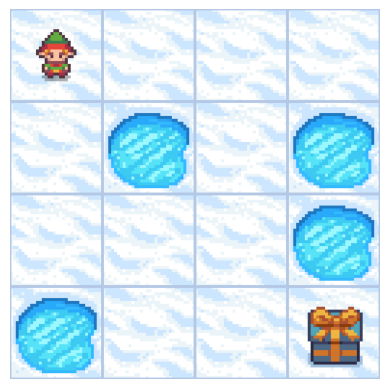

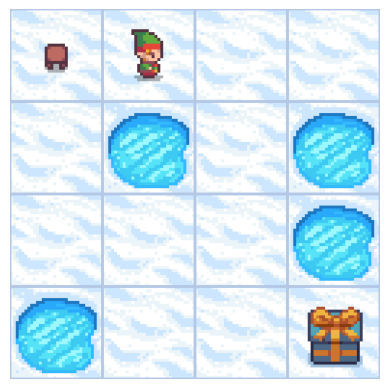

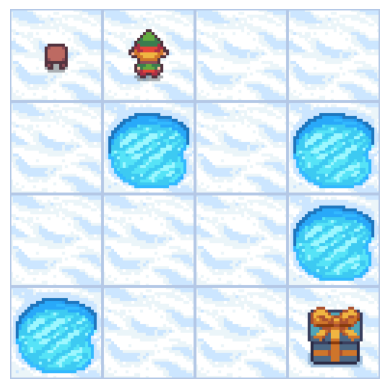

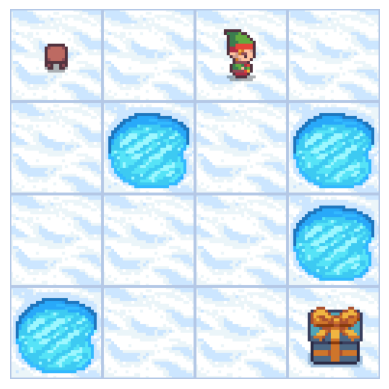

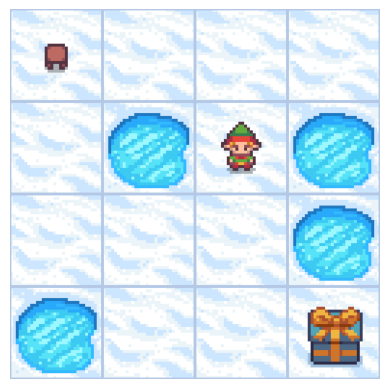

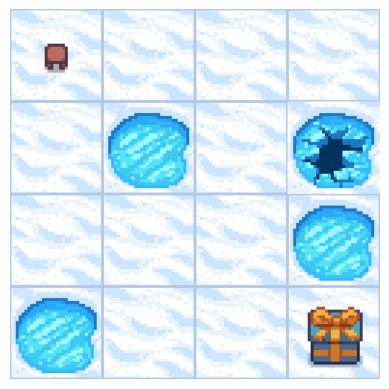

Beispiel Episode:
[(0, np.int64(2), 0.0), (1, np.int64(3), 0.0), (1, np.int64(2), 0.0), (2, np.int64(1), 0.0), (6, np.int64(2), 0.0)]


In [66]:
render = True # Flag zum Steuern der Visualisierung (separate Flags werden in die Codezellen geschrieben)

def generate_episode(env, max_steps=100):
    episode = []
    state, info = env.reset(seed=100)
    
    
    if render: 
        show_frame(env.render())

    for _ in range(max_steps):
        action = env.action_space.sample()  # Zufällige Aktion auswählen
        next_state, reward, done, truncated, info = env.step(action)  # Aktion ausführen und Feedback erhalten

        episode.append((state, action, reward))  # State, Aktion und Reward speichern
        state = next_state  # Zum nächsten Zustand wechseln

        if render:
            show_frame(env.render())  # Frame für die Visualisierung anzeigen

        if done or truncated:  # Episode beenden, wenn Ziel erreicht oder vorzeitig abgebrochen
            break

    return episode

episode = generate_episode(env)
print("Beispiel Episode:")
print(episode)

**Return berechnen**

Für Monte Carlo brauchen wir wie oben schon geschrieben den Return R ab einem bestimmten Zeitpunkt t:

Da hier zunächst mit einem Discount-Faktor von gamma = 1.0 gearbeitet wird, ist der Return einfach die Summe aller zukünftigen Rewards ab Zeitpunkt t:

Formal:
> G_t = R_{t+1} + R_{t+2} + R_{t+3} + ... + R

Einfach gesagt: Es werden die Rewards summiert vom aktellen Zeitpunkt t bis zum Ende der Episode.

In [48]:
def compute_return(episode, start_index, gamma=1.0):
    G = 0
    discount = 1.0
    for _, _, reward in episode[start_index:]:
        G += discount * reward
        discount *= gamma
    
    return G

**First-Visit Monte Carlo**

In dieser Methode wird pro Episode nur das **erste Auftreten** eines State-Action-Paares berücksichtigt

Die Logik ist:
1. Episode generieren
2. pro Episode merken, welche State-Action-Paare schon gesehen wurden
3. nur beim ersten Aufrteten den Return berechnen
4. Returns aufsummieren
5. durch Anzahl der Besuche teilen um den Q-Wert zu schätzen

In [60]:
render = False # Flag zum Steuern der Visualisierung in der First-Visit-Methode

def first_visit_mc(env, num_episodes=100, gamma=1.0):
    Q = np.zeros((num_states, num_actions))  # Q-Werte initialisieren
    returns_sum = np.zeros((num_states, num_actions))  # Summe der Returns für jedes State-Action-Paar
    returns_count = np.zeros((num_states, num_actions))  # Anzahl der Besuche für jedes State-Action-Paar

    for _ in range(num_episodes):
        episode = generate_episode(env) # Episode generieren
        visited_state_actions = set()  # Set, um besuchte State-Action-Paare zu verfolgen

        for t, (state, action, reward) in enumerate(episode):
            if (state, action) not in visited_state_actions:
                G = compute_return(episode, t, gamma)  # Return ab Zeitpunkt t berechnen
                returns_sum[state, action] += G  # Return zur Summe hinzufügen
                returns_count[state, action] += 1  # Besuchszähler erhöhen
                visited_state_actions.add((state, action))  # State-Action-Paar als besucht markieren

    nonzero = returns_count != 0   # Vermeidung von Division durch Null
    Q[nonzero] = returns_sum[nonzero] / returns_count[nonzero]  # Durchschnitts-Return berechnen

    return Q

**Every-Visit Monte Carlo**

Every-Visit funktioniert fast identisch, berücksichtigt aber jede Beobachtung eines State-Action-Paares innerhalb einer Episode.

Dadurch werden mehr Updates durchgeführt, was mehr Informationen nutzt aber auch etwas mehr Varianz bringen kann.

In [61]:
render = False # Flag zum Steuern der Visualisierung in der Every-Visit-Methode

def every_visit_mc(env, num_episodes=100, gamma=1.0):
    Q = np.zeros((num_states, num_actions))  # Q-Werte initialisieren
    returns_sum = np.zeros((num_states, num_actions))  # Summe der Returns für jedes State-Action-Paar
    returns_count = np.zeros((num_states, num_actions))  # Anzahl der Besuche für jedes State-Action-Paar

    for _ in range(num_episodes):
        episode = generate_episode(env)  # Episode generieren

        for t, (state, action, reward) in enumerate(episode):
            G = compute_return(episode, t, gamma)  # Return ab Zeitpunkt t berechnen
            returns_sum[state, action] += G  # Return zur Summe hinzufügen
            returns_count[state, action] += 1  # Besuchszähler erhöhen

    nonzero = returns_count != 0   # Vermeidung von Division durch Null
    Q[nonzero] = returns_sum[nonzero] / returns_count[nonzero]  # Durchschnitts-Return berechnen

    return Q

**Policy aus der Q-Tabelle ableiten**

Sobald die Q-Werte geschätzt wurden. kann für jeden State die Action mit dem höchsten Q-Wert ausgewählt werden

Damit entsteht eine Greedy Policy bezüglich der geschätzten Q-Werte, die sich mit mehr Episoden und Updates immer weiter verbessert.

In [62]:
def get_policy(Q):
    return {state: int(np.argmax(Q[state])) for state in range(num_states)}

In [63]:
Q_first = first_visit_mc(env, num_episodes=1000, gamma=1.0)
policy_first = get_policy(Q_first)

Q_every = every_visit_mc(env, num_episodes=1000, gamma=1.0)
policy_every = get_policy(Q_every)

print("First-Visit Policy:")
print(policy_first)

print("\nEvery-Visit Policy:")
print(policy_every)

First-Visit Policy:
{0: 1, 1: 2, 2: 1, 3: 0, 4: 1, 5: 0, 6: 1, 7: 0, 8: 2, 9: 1, 10: 1, 11: 0, 12: 0, 13: 2, 14: 2, 15: 0}

Every-Visit Policy:
{0: 1, 1: 2, 2: 1, 3: 0, 4: 1, 5: 0, 6: 1, 7: 0, 8: 2, 9: 1, 10: 1, 11: 0, 12: 0, 13: 2, 14: 2, 15: 0}
